In [1]:
import ast
from collections import Counter

import numpy as np
import optuna
import pandas as pd
from pathlib import Path

In [2]:
data_root = Path('/home/ubuntu/data/v0_6')
ref_root = Path('/home/ubuntu/data/reference_data')
hpo_output_dir = data_root / 'hpo'
study = optuna.load_study(                                                
  study_name='biojepa_v0_6_hpo_v14_phase1',
  storage=f'sqlite:///{hpo_output_dir / "biojepa_v0_6_hpo_v14_phase1"}.db'
)

In [3]:
for trial in study.trials:
    state = trial.state.name
    reason = trial.user_attrs.get('fail_reason', 'N/A')
    params = {k: trial.params.get(k, '?') for k in ['embed_dim', 'n_layer', 'heads']}
    print(f'Trial {trial.number}: {state} | D={params["embed_dim"]} L={params["n_layer"]} H={params["heads"]} | {reason}')

states = Counter(t.state.name for t in study.trials)
reasons = Counter(t.user_attrs.get('fail_reason', 'N/A') for t in study.trials if t.state.name
!= 'COMPLETE')
print(f'\nState counts: {dict(states)}')
print(f'Fail reasons: {dict(reasons)}')

Trial 0: COMPLETE | D=256 L=6 H=4 | N/A
Trial 1: COMPLETE | D=256 L=6 H=4 | N/A
Trial 2: COMPLETE | D=256 L=6 H=4 | N/A
Trial 3: COMPLETE | D=256 L=6 H=4 | N/A
Trial 4: RUNNING | D=256 L=6 H=4 | N/A

State counts: {'COMPLETE': 4, 'RUNNING': 1}
Fail reasons: {'N/A': 1}


In [4]:
for trial in study.trials[:]:
    print(f'Trial {trial.number}: user_attrs={trial.user_attrs}, system_attrs={trial.system_attrs}')

Trial 0: user_attrs={'eval_10000': {'pert_auroc': 0.5233, 'eff_dim_90': 16, 'dead_dims': 0, 'recon_pearson': 0.96, 'invariance_ratio': 0.3, 'kegg_silhouette': -0.0474, 'cell_type_acc': 0.8999, 'essential_auroc': 0.6389, 'consistency_ratio': 0.9266}, 'eval_15000': {'pert_auroc': 0.5471, 'eff_dim_90': 17, 'dead_dims': 0, 'recon_pearson': 0.9556, 'invariance_ratio': 0.25, 'kegg_silhouette': -0.0503, 'essential_auroc': 0.6392, 'consistency_ratio': 0.7444}, 'eval_20000': {'pert_auroc': 0.5754, 'eff_dim_90': 15, 'dead_dims': 0, 'recon_pearson': 0.9644, 'invariance_ratio': 0.32, 'kegg_silhouette': -0.0494, 'cell_type_acc': 0.8929, 'essential_auroc': 0.6356, 'consistency_ratio': 1.0046}, 'eval_25000': {'pert_auroc': 0.5446, 'eff_dim_90': 15, 'dead_dims': 0, 'recon_pearson': 0.9545, 'invariance_ratio': 0.1852, 'kegg_silhouette': -0.0506, 'essential_auroc': 0.6367, 'consistency_ratio': 0.717}, 'eval_30000': {'pert_auroc': 0.564, 'eff_dim_90': 16, 'dead_dims': 0, 'recon_pearson': 0.9456, 'invaria

In [5]:
importances = optuna.importance.get_param_importances(study)                     
importances     

{'mask_ratio': np.float64(0.20121406533768404),
 'film_linear_multiple': np.float64(0.17803783250450608),
 'ema_momentum': np.float64(0.16925683273297207),
 'lr': np.float64(0.16506029648576168),
 'vicreg_weight': np.float64(0.16402897928788812),
 'gaussian_scale': np.float64(0.12240199365118798),
 'n_layer': np.float64(0.0),
 'heads': np.float64(0.0),
 'embed_dim': np.float64(0.0)}

/tmp/ipykernel_126077/2210069751.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study)
/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/optuna/visualization/matplotlib/_slice.py:146: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim[0], xlim[1])


array([<Axes: xlabel='ema_momentum', ylabel='Objective Value'>,
       <Axes: xlabel='embed_dim'>, <Axes: xlabel='film_linear_multiple'>,
       <Axes: xlabel='gaussian_scale'>, <Axes: xlabel='heads'>,
       <Axes: xlabel='lr'>, <Axes: xlabel='mask_ratio'>,
       <Axes: xlabel='n_layer'>, <Axes: xlabel='vicreg_weight'>],
      dtype=object)

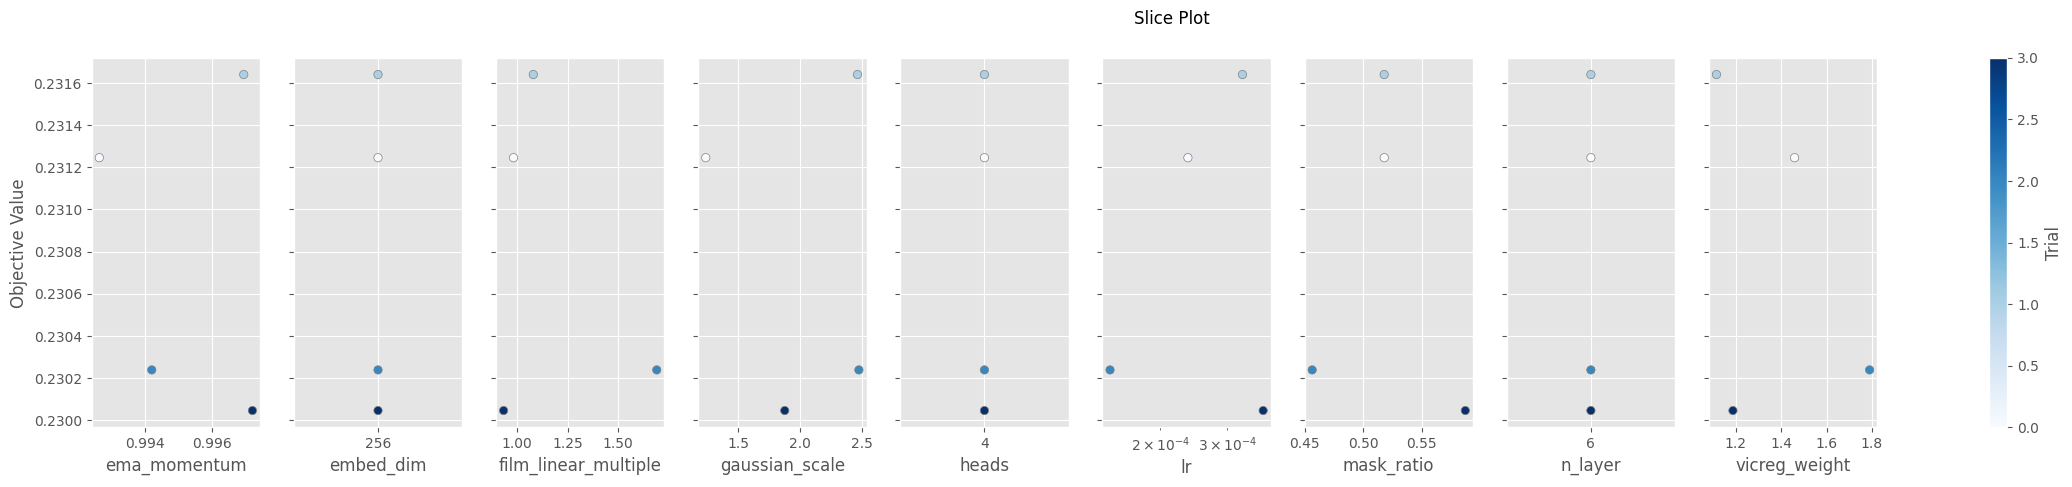

In [6]:
optuna.visualization.matplotlib.plot_slice(study)   

In [7]:
df = study.trials_dataframe()
completed = df[df['value'].notna()]
k = max(20, len(completed) // 20)
top_k = completed.nlargest(k, 'value')

continuous_params = [c for c in completed.columns if c.startswith('params_') ]
centroid = top_k[continuous_params].median()
centroid_std = top_k[continuous_params].std()

top_k[['number', 'value'] + continuous_params]

,number,value,params_ema_momentum,params_embed_dim,params_film_linear_multiple,params_gaussian_scale,params_heads,params_lr,params_mask_ratio,params_n_layer,params_vicreg_weight
1,1,0.231640,0.996962,256,1.079413,2.464128,4,0.000329,0.517874,6,1.115274
0,0,0.231245,0.992642,256,0.981501,1.238026,4,0.000236,0.517911,6,1.459317
2,2,0.230239,0.994211,256,1.691178,2.475323,4,0.000148,0.456276,6,1.789558
3,3,0.230046,0.997222,256,0.932251,1.876387,4,0.000372,0.587247,6,1.187808


In [8]:
centroid, centroid_std

(params_ema_momentum              0.995586
 params_embed_dim               256.000000
 params_film_linear_multiple      1.030457
 params_gaussian_scale            2.170258
 params_heads                     4.000000
 params_lr                        0.000282
 params_mask_ratio                0.517893
 params_n_layer                   6.000000
 params_vicreg_weight             1.323563
 dtype: float64,
 params_ema_momentum            0.002213
 params_embed_dim               0.000000
 params_film_linear_multiple    0.352082
 params_gaussian_scale          0.587794
 params_heads                   0.000000
 params_lr                      0.000100
 params_mask_ratio              0.053515
 params_n_layer                 0.000000
 params_vicreg_weight           0.305936
 dtype: float64)

In [9]:
df.to_csv(hpo_output_dir / f'biojepa_v0_6_hpo_v14_results.csv', index=False)

In [10]:
WEIGHTS = {
    'pert': 0.15, 'batch_inv': 0.15, 'recon': 0.15, 'health': 0.15,
    'pathway': 0.20, 'essential': 0.10, 'consist': 0.10,
}

completed = [t for t in study.trials if t.state.name == 'COMPLETE']

rows = []
for t in completed:
    final = t.user_attrs.get('eval_final', {})
    if isinstance(final, str):
        final = ast.literal_eval(final)

    eff_dim_pct = final.get('eff_dim_90', 128) / 256
    dim_score = max(0, min(1, (eff_dim_pct - 0.3) / 0.5))
    dead_score = max(0, 1 - (final.get('dead_dims', 0) / 256) / 0.02)
    kegg_sil = final.get('kegg_silhouette', -0.05)
    consist_ratio = final.get('consistency_ratio', 1.0)

    norm = {
        'pert': max(0, (final.get('pert_auroc', 0.5) - 0.5) * 2),
        'batch_inv': min(1.0, final.get('invariance_ratio', 0) / 5.0),
        'recon': final.get('recon_pearson', 0),
        'health': 0.7 * dim_score + 0.3 * dead_score,
        'pathway': max(0, min(1, (kegg_sil + 0.05) / 0.15)),
        'essential': max(0, (final.get('essential_auroc', 0.5) - 0.5) * 2),
        'consist': max(0, min(1, (consist_ratio - 1.0) / 1.0)),
    }

    row = {'trial': t.number, 'composite': t.value, 'heads': t.params.get('heads', '?')}
    for k in WEIGHTS:
        row[f'{k}_norm'] = round(norm[k], 4)
        row[f'{k}_wtd'] = round(WEIGHTS[k] * norm[k], 4)
    rows.append(row)

decomp = pd.DataFrame(rows).set_index('trial').sort_values('composite', ascending=False)
wtd_cols = [c for c in decomp.columns if c.endswith('_wtd')]
decomp[['composite', 'heads'] + wtd_cols]

,composite,heads,pert_wtd,batch_inv_wtd,recon_wtd,health_wtd,pathway_wtd,essential_wtd,consist_wtd
trial,,,,,,,,,
1,0.231640,4,0.0063,0.0043,0.1442,0.045,0.0,0.0289,0.0030
0,0.231245,4,0.0077,0.0072,0.1434,0.045,0.0,0.0279,0.0000
2,0.230239,4,0.0120,0.0060,0.1432,0.045,0.0,0.0238,0.0002
3,0.230046,4,0.0082,0.0062,0.1456,0.045,0.0,0.0243,0.0008


In [11]:
wtd_df = decomp[wtd_cols]
summary = pd.DataFrame({
    'weight': {c.replace('_wtd', ''): WEIGHTS[c.replace('_wtd', '')] for c in wtd_cols},
    'mean_contribution': wtd_df.mean(),
    'std_contribution': wtd_df.std(),
    'range': wtd_df.max() - wtd_df.min(),
}).rename(index=lambda x: x.replace('_wtd', ''))
summary.sort_values('range', ascending=False)

,weight,mean_contribution,std_contribution,range
pert,NaN,0.008550,0.002437,0.0057
essential,NaN,0.026225,0.002553,0.0051
consist,NaN,0.001000,0.001376,0.0030
batch_inv,NaN,0.005925,0.001204,0.0029
recon,NaN,0.144100,0.001089,0.0024
health,NaN,0.045000,0.000000,0.0000
pathway,NaN,0.000000,0.000000,0.0000
batch_inv,0.15,NaN,NaN,NaN
consist,0.10,NaN,NaN,NaN
essential,0.10,NaN,NaN,NaN


In [12]:
checkpoint_keys = sorted([k for k in completed[0].user_attrs if k.startswith('eval_')], key=lambda x: int(x.split('_')[1]) if x != 'eval_final' else 999999)

inv_rows = []
for t in completed:
    for ck in checkpoint_keys:
        ev = t.user_attrs.get(ck, {})
        if isinstance(ev, str):
            ev = ast.literal_eval(ev)
        if not ev:
            continue
        step = 999999 if ck == 'eval_final' else int(ck.split('_')[1])
        inv_rows.append({'trial': t.number, 'step': step, 'invariance_ratio': ev.get('invariance_ratio', np.nan)})

inv_df = pd.DataFrame(inv_rows).pivot(index='trial', columns='step', values='invariance_ratio')
inv_df.columns = [f'step_{c}' if c != 999999 else 'final' for c in inv_df.columns]
inv_df['composite'] = decomp['composite']
inv_df.sort_values('composite', ascending=False)

,step_5000,step_10000,step_15000,step_20000,step_25000,step_30000,final,composite
trial,,,,,,,,
1,0.3684,0.1923,0.1290,0.2857,0.1923,0.1429,0.1429,0.231640
0,0.3200,0.3000,0.2500,0.3200,0.1852,0.2400,0.2400,0.231245
2,0.3000,0.2609,0.3200,0.4118,0.2143,0.2000,0.2000,0.230239
3,0.3043,0.1429,0.1724,0.1515,0.1923,0.2059,0.2059,0.230046


# Reweighted ranking (post-hoc)

In [ ]:
def reweight_trials(completed_trials, custom_weights, embed_dim=256):
    '''Recompute composite scores with custom weights. Weights are auto-normalized to sum to 1.'''
    w_sum = sum(custom_weights.values())
    w_norm = {k: v / w_sum for k, v in custom_weights.items()}

    rows = []
    for t in completed_trials:
        final = t.user_attrs.get('eval_final', {})
        if isinstance(final, str):
            final = ast.literal_eval(final)

        eff_dim_pct = final.get('eff_dim_90', embed_dim // 2) / embed_dim
        dim_score = max(0, min(1, (eff_dim_pct - 0.3) / 0.5))
        dead_score = max(0, 1 - (final.get('dead_dims', 0) / embed_dim) / 0.02)

        all_norm = {
            'pert': max(0, (final.get('pert_auroc', 0.5) - 0.5) * 2),
            'batch_inv': min(1.0, final.get('invariance_ratio', 0) / 5.0),
            'recon': final.get('recon_pearson', 0),
            'health': 0.7 * dim_score + 0.3 * dead_score,
            'pathway': max(0, min(1, (final.get('kegg_silhouette', -0.05) + 0.05) / 0.15)),
            'essential': max(0, (final.get('essential_auroc', 0.5) - 0.5) * 2),
            'consist': max(0, min(1, (final.get('consistency_ratio', 1.0) - 1.0) / 1.0)),
        }

        score = sum(w_norm.get(k, 0) * all_norm[k] for k in all_norm)
        row = {
            'trial': t.number, 'score': round(score, 4),
            'lr': f'{t.params.get("lr", 0):.1e}', 'ema': round(t.params.get('ema_momentum', 0), 4),
            'gaussian': round(t.params.get('gaussian_scale', 0), 2),
            'vicreg': round(t.params.get('vicreg_weight', 0), 2),
            'mask': round(t.params.get('mask_ratio', 0), 2),
            'film': round(t.params.get('film_linear_multiple', 0), 2),
            'pert': round(final.get('pert_auroc', 0), 4),
            'essential': round(final.get('essential_auroc', 0), 4),
            'recon': round(final.get('recon_pearson', 0), 4),
            'pathway': round(final.get('kegg_silhouette', 0), 4),
            'consist': round(final.get('consistency_ratio', 0), 4),
            'batch_inv': round(final.get('invariance_ratio', 0), 4),
        }
        rows.append(row)

    return pd.DataFrame(rows).set_index('trial').sort_values('score', ascending=False)


# Weight schemes to compare
schemes = {
    'original': {'pert': 0.15, 'batch_inv': 0.15, 'recon': 0.15, 'health': 0.15, 'pathway': 0.20, 'essential': 0.10, 'consist': 0.10},
    'discriminative': {'pert': 0.30, 'essential': 0.30, 'consist': 0.15, 'batch_inv': 0.10, 'recon': 0.10, 'health': 0.05},
    'bio_signal': {'pert': 0.35, 'essential': 0.35, 'pathway': 0.10, 'consist': 0.10, 'recon': 0.10},
}

completed = [t for t in study.trials if t.state.name == 'COMPLETE']
for name, weights in schemes.items():
    print(f'\n=== {name} ===')
    w_sum = sum(weights.values())
    print({k: round(v / w_sum, 2) for k, v in weights.items()})
    display(reweight_trials(completed, weights))